In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load raw dataset
df_raw = pd.read_csv("../data/raw/city_day.csv")
df_city = (
    df_raw[df_raw["City"] == "Delhi"]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)
df_city["Date"] = pd.to_datetime(df_city["Date"])

print(f"Total Delhi records: {len(df_city)}")
df_city.head(3)

Total Delhi records: 2009


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
1,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
2,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate


Missing percentage per column:
 PM2.5          0.10
PM10           3.83
NO             0.10
NO2            0.10
NH3            0.45
SO2            5.48
O3             4.18
Xylene        38.88
AQI            0.50
AQI_Bucket     0.50
dtype: float64


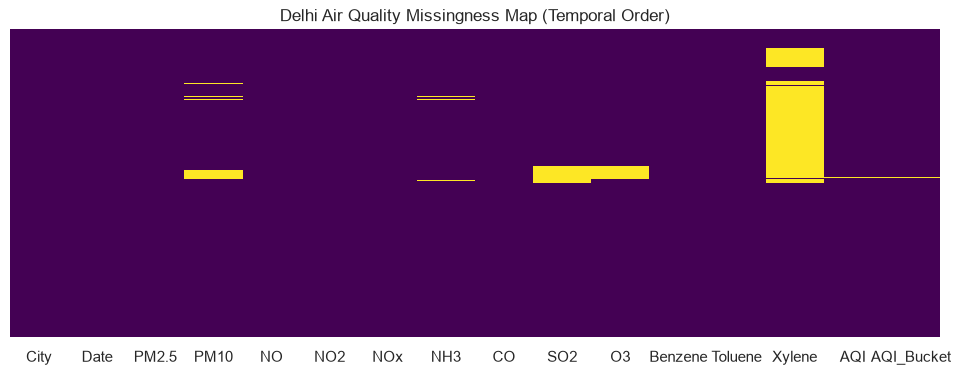

In [2]:
missing_pct = (df_city.isnull().sum() / len(df_city) * 100).round(2)
print("Missing percentage per column:\n", missing_pct[missing_pct > 0])

plt.figure(figsize=(12, 4))
sns.heatmap(
    df_city.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis",
)
plt.title("Delhi Air Quality Missingness Map (Temporal Order)")
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_12156\1225714855.py:21: SyntaxWarning: invalid escape sequence '\m'
  label="NAAQS Daily Standard (60 $\mu g/m^3$)",
C:\Users\HP\AppData\Local\Temp\ipykernel_12156\1225714855.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu g/m^3$")


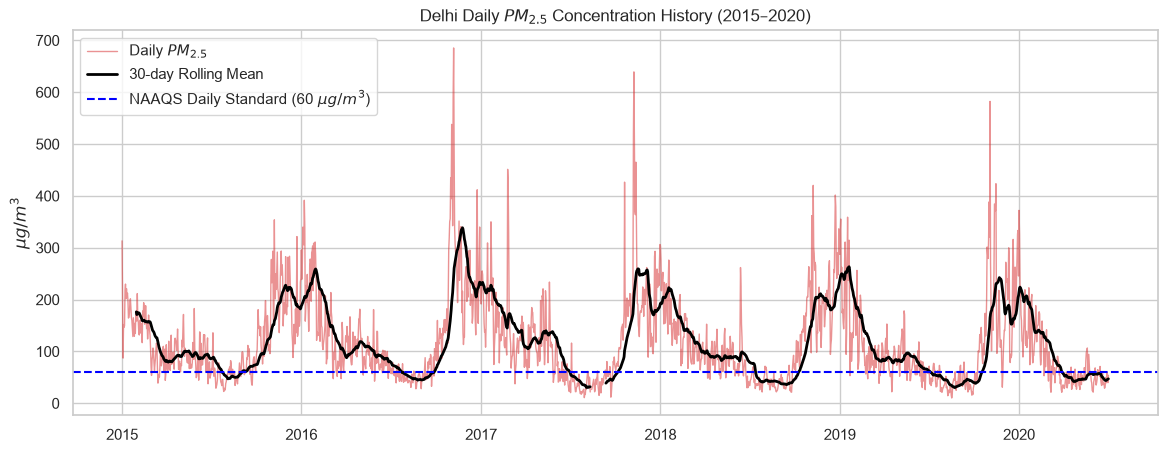

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(
    df_city["Date"],
    df_city["PM2.5"],
    label="Daily $PM_{2.5}$",
    color="#d62728",
    alpha=0.5,
    lw=1,
)
plt.plot(
    df_city["Date"],
    df_city["PM2.5"].rolling(30).mean(),
    label="30-day Rolling Mean",
    color="black",
    lw=2,
)
plt.axhline(
    60,
    color="blue",
    linestyle="--",
    label="NAAQS Daily Standard (60 $\mu g/m^3$)",
)
plt.title("Delhi Daily $PM_{2.5}$ Concentration History (2015–2020)")
plt.ylabel("$\mu g/m^3$")
plt.legend()
plt.show()

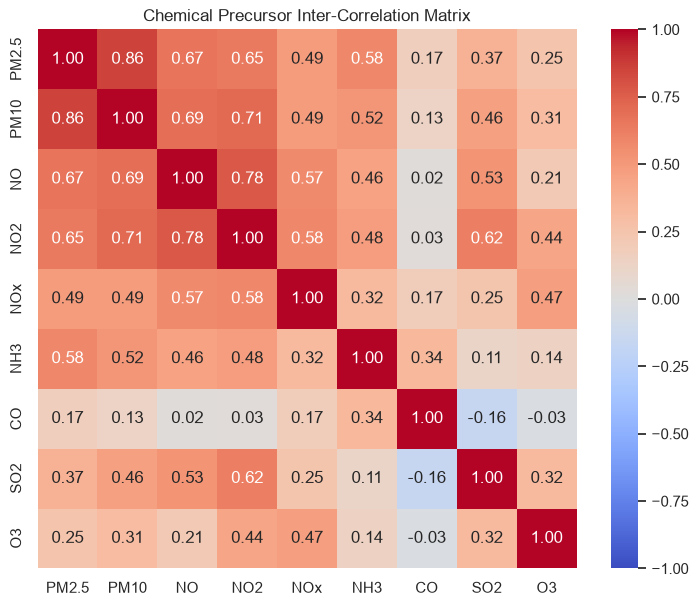

In [4]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
]
corr = df_city[pollutants].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Chemical Precursor Inter-Correlation Matrix")
plt.show()